# Cramér-Rao Bound

The **Cramér-Rao bound** (CRB) is the theoretical lower limit on the variance of any unbiased estimator of a parameter. For a model with parameter vector $\boldsymbol{\theta}$, the CRB is the diagonal of the inverse Fisher information matrix:

$$\mathrm{Var}(\hat{\theta}_i) \geq \left[\mathcal{I}(\boldsymbol{\theta})^{-1}\right]_{ii}$$

For a Gaussian process with covariance matrix $K(\boldsymbol{\theta})$, the Fisher information matrix has the analytic form

$$\mathcal{I}_{ij}(\boldsymbol{\theta}) = \frac{1}{2} \mathrm{Tr}\!\left[ K^{-1} \frac{\partial K}{\partial \theta_i} K^{-1} \frac{\partial K}{\partial \theta_j} \right]$$

The CRB answers: **given this dataset and this model, what is the best precision any method could achieve?** It is independent of the fitting algorithm and characterizes the intrinsic information content of the data.

```{admonition} Sections

1. Simulate a synthetic lightcurve from known true parameters.
2. Compute the Fisher information matrix at the truth using automatic differentiation.
3. Examine the CRB for each kernel parameter — both individually and as 2D confidence ellipses.
4. Explore how the CRB depends on the noise level and observation baseline.
```

In [ ]:

import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append("../..")
from src import (
    TrapezoidSymmetricEnvelope,
    VisibilityFunction,
    SpotEvolutionModel,
    LightcurveModel,
    GPSolver,
)

np.random.seed(60)

plt.rcParams.update({                                                                                  
    "font.size":        16,   # base font size                                                         
    "axes.titlesize":   20,   # axes title                                                             
    "axes.labelsize":   18,   # x/y axis labels                                                        
    "xtick.labelsize":  14,   # x tick labels                                                          
    "ytick.labelsize":  14,   # y tick labels                                                          
    "legend.fontsize":  14,                                                                            
    "figure.titlesize": 22,   # suptitle
    "axes.formatter.useoffset": False,  # disable scientific notation offset                                                   
})   

## 1. Simulate a Synthetic Lightcurve

We define a ground-truth `SpotEvolutionModel` with known parameters, simulate a noisy lightcurve, and save these as the "observed" dataset. The true parameters will later serve as the point at which we evaluate the Fisher information.

```{important}
True parameters must be **strictly inside** the prior bounds — not on the boundary. A parameter sitting exactly at a bound places the evaluation point at a corner of the prior support where the Hessian is degenerate (the curvature is one-sided), causing the Fisher information matrix to be near-singular and the CRB to blow up.
```

In [2]:
# --- True kernel hyperparameters (must be interior to bounds below) ---
true_params = dict(
    peq      = 3.0,          # equatorial rotation period [days]
    kappa    = 0.3,          # differential rotation shear
    inc      = np.pi / 3,     # inclination [rad]  (60°)
    lspot    = 12.0,           # spot plateau duration [days]
    tau_spot = 8.0,           # spot rise/decay timescale [days]
    sigma_k  = 0.03,          # kernel amplitude
)
sigma_n = 1e-4               # per-point photometric noise

# Prior bounds — true params are well inside each interval
bounds = dict(
    peq      = (3.0,  30.0),
    kappa    = (0.0,   0.5),
    inc      = (0.1, np.pi / 2),
    lspot    = (1.0,  20.0),
    tau_spot = (1.0,  20.0),
    sigma_k  = (1e-3,  0.3),
)

envelope   = TrapezoidSymmetricEnvelope(lspot=true_params["lspot"], tau_spot=true_params["tau_spot"])
visibility = VisibilityFunction(peq=true_params["peq"], kappa=true_params["kappa"], inc=true_params["inc"])
model      = SpotEvolutionModel(envelope=envelope, visibility=visibility, sigma_k=true_params["sigma_k"])

In [3]:
tsim  = 200
tsamp = 0.5

lc    = LightcurveModel.from_spot_model(model, nspot_rate=0.25, tsim=tsim, tsamp=tsamp)
t_obs = lc.t
y_obs = lc.flux + np.random.normal(0, sigma_n, len(t_obs))
y_err = np.full(len(t_obs), sigma_n)

print(f"N_obs = {len(t_obs)},  baseline = {t_obs[-1]:.0f} d,  cadence = {np.median(np.diff(t_obs)):.2f} d")

N_obs = 400,  baseline = 200 d,  cadence = 0.50 d


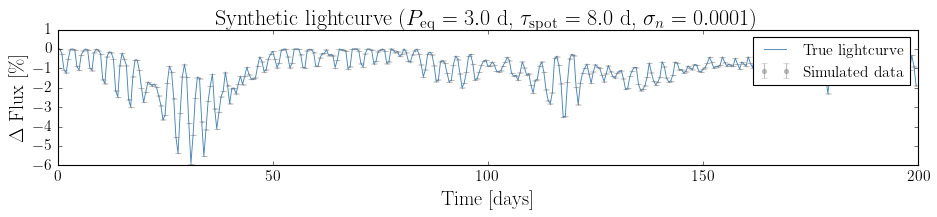

In [4]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.errorbar(t_obs, (y_obs - 1) * 100, yerr=sigma_n * 100,
            fmt=".", ms=2, alpha=0.5, color="gray", label="Simulated data")
ax.plot(t_obs, (lc.flux - 1) * 100, color="steelblue", lw=0.8, label="True lightcurve")
ax.set_xlabel("Time [days]")
ax.set_ylabel(r"$\Delta$ Flux [\%]")
ax.set_title(f"Synthetic lightcurve  ($P_{{\\rm eq}}={true_params['peq']}$ d, "
             f"$\\tau_{{\\rm spot}}={true_params['tau_spot']}$ d, "
             f"$\\sigma_n={sigma_n}$)")
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

## 2. Compute the Fisher Information Matrix

The Fisher information matrix is defined as the **expectation** of the Hessian of the negative log-likelihood over all noise realizations:

$$\mathcal{I}_{ij}(\boldsymbol{\theta}) = \frac{1}{2}\mathrm{Tr}\!\left[K^{-1}\frac{\partial K}{\partial\theta_i}K^{-1}\frac{\partial K}{\partial\theta_j}\right]$$

This expression depends only on $K(\boldsymbol{\theta}_{\rm true})$, not on the specific noise realization $\mathbf{y}$, so it is always positive semi-definite. The CRB covariance matrix is its inverse: $\Sigma_{\rm CRB} = \mathcal{I}^{-1}$.

```{important}
Do **not** use the observed Hessian of the log-likelihood evaluated at the true parameters. The true parameters are generally not the MAP for a particular noise realization, so the observed Hessian includes a stochastic noise term that can make eigenvalues negative and cause the CRB to blow up. Use `mass_matrix_fisher()` with `matrix_solver="cholesky_full"` instead, which evaluates the analytic trace formula above via forward-mode AD on the kernel matrix.
```

In [5]:
# Use cholesky_full so mass_matrix_fisher() can evaluate the analytic trace formula
# via jacfwd on the full N×N kernel matrix.
gp = GPSolver(t_obs, y_obs, y_err, model, matrix_solver="cholesky_full").build_jax()

JAX GP solver compiled in 3.42s
JAX GP solver recompute in 0.42s


In [6]:
# gp.theta0 is initialized from the true model parameters
theta_true = gp.theta0

# Analytic Fisher information: I_ij = (1/2) Tr[K^{-1} dK/dtheta_i  K^{-1} dK/dtheta_j]
# Returns the inverse Fisher (= CRB covariance matrix); always PSD.
cov_crb   = np.array(gp.mass_matrix_fisher(theta_true))
sigma_crb = np.sqrt(np.diag(cov_crb))

param_keys = list(gp.param_keys)
true_vals  = [float(theta_true[i]) for i in range(len(param_keys))]

### CRB summary table

For each parameter we report: the true value, the CRB standard deviation $\sigma_{\rm CRB}$, and the **relative precision** $\sigma_{\rm CRB} / |\theta_{\rm true}|$.

In [7]:
param_labels = {
    "peq":      r"$P_{\rm eq}$ [d]",
    "kappa":    r"$\kappa$",
    "inc":      r"$i$ [rad]",
    "lspot":    r"$\ell_{\rm spot}$ [d]",
    "tau_spot": r"$\tau_{\rm spot}$ [d]",
    "sigma_k":  r"$\sigma_k$",
}

print(f"{'Parameter':<16} {'True value':>12} {'σ_CRB':>10} {'Relative [%]':>14}")
print("-" * 56)
for k, v, s in zip(param_keys, true_vals, sigma_crb):
    rel = s / abs(v) * 100 if v != 0 else float("inf")
    print(f"{k:<16} {v:>12.4f} {s:>10.4f} {rel:>13.1f}%")

Parameter          True value      σ_CRB   Relative [%]
--------------------------------------------------------
peq                    3.0000     0.0116           0.4%
kappa                  0.3000     0.0159           5.3%
inc                    1.0472     0.0296           2.8%
lspot                 12.0000     0.2437           2.0%
tau_spot               8.0000     0.4226           5.3%
sigma_k                0.0300     0.0014           4.6%


## 3. Visualizing the CRB

### Relative precision by parameter

The bar chart below shows the minimum fractional uncertainty $\sigma_{\rm CRB}/|\theta|$ for each parameter. Parameters whose values strongly shape the GP kernel (e.g. $P_{\rm eq}$, $\sigma_k$) tend to have tight CRBs. Parameters that enter more weakly or are partially degenerate (e.g. $\kappa$, $i$) have looser bounds.

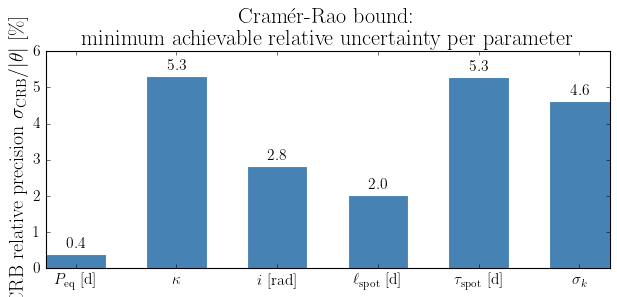

In [8]:
rel_sigma = [s / abs(v) * 100 for v, s in zip(true_vals, sigma_crb)]
labels    = [param_labels.get(k, k) for k in param_keys]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, rel_sigma, color="steelblue", edgecolor="white", width=0.6)
ax.set_ylabel(r"CRB relative precision  $\sigma_{\rm CRB} / |\theta|$ [\%]")
ax.set_title("Cramér-Rao bound: \n minimum achievable relative uncertainty per parameter")
for bar, val in zip(bars, rel_sigma):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=14)
plt.tight_layout()
plt.show()

### 2D confidence ellipses

The off-diagonal elements of $\Sigma_{\rm CRB}$ encode **parameter correlations** — directions in parameter space that are jointly constrained or degenerate. The 1$\sigma$ and 2$\sigma$ confidence ellipses are the level sets of the quadratic form $(\boldsymbol{\theta} - \boldsymbol{\theta}_{\rm true})^\top \Sigma_{\rm CRB}^{-1} (\boldsymbol{\theta} - \boldsymbol{\theta}_{\rm true}) = 2.30,\, 6.18$ (for 68% and 95% in 2D).

Below we show a corner plot for a subset of the most physically interesting parameters.

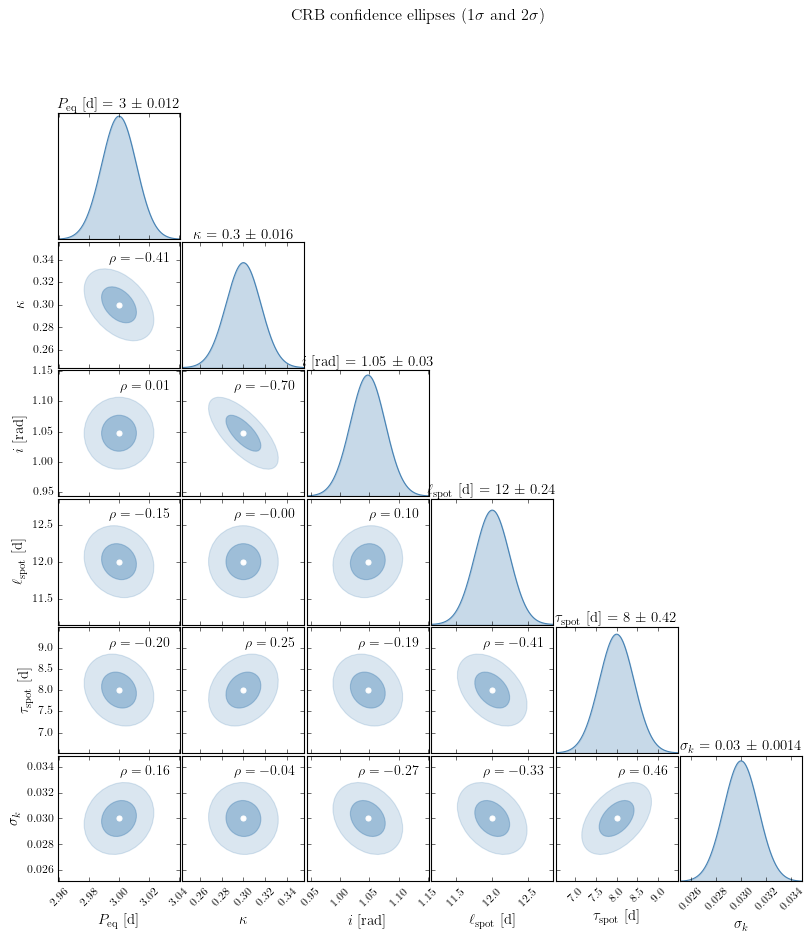

In [10]:
from src import crb_corner_plot                                                                        
                                                                                                        
fig, axes = crb_corner_plot(                                                                           
    cov_crb,                                                                                           
    param_keys,                                                                                      
    true_vals,                                                                                         
    corner_keys=list(true_params.keys()),
    param_labels=param_labels,                                                                         
    panel_size=2.0,                                   
    base_fontsize=20,                                                                                  
)                                                                                                      
plt.show()

## 4. Dependence on Noise Level and Observation Baseline

The Fisher information scales with the number of independent observations and their signal-to-noise ratio. In the large-sample limit:

$$\mathcal{I}(\boldsymbol{\theta}) \propto \frac{T}{\sigma_n^2}$$

so $\sigma_{\rm CRB} \propto \sigma_n / \sqrt{T}$ — halving the noise or quadrupling the baseline each halves the minimum uncertainty. Below we verify this by computing the CRB across a grid of noise levels and observation baselines.

### Effect of noise level

In [41]:
sigma_n_vals = [0.001, 0.002, 0.005, 0.01, 0.02]
crb_vs_noise = {k: [] for k in param_keys}

for sn in sigma_n_vals:
    y_i   = lc.flux + np.random.normal(0, sn, len(t_obs))
    ye_i  = np.full(len(t_obs), sn)
    gp_i  = GPSolver(t_obs, y_i, ye_i, model, matrix_solver="cholesky_full").build_jax()
    cov_i = np.array(gp_i.mass_matrix_fisher(gp_i.theta0))
    for k, s in zip(param_keys, np.sqrt(np.diag(cov_i))):
        crb_vs_noise[k].append(s)

JAX GP solver compiled in 2.93s
JAX GP solver recompute in 0.43s
JAX GP solver compiled in 3.02s
JAX GP solver recompute in 0.45s
JAX GP solver compiled in 3.13s
JAX GP solver recompute in 0.45s
JAX GP solver compiled in 2.95s
JAX GP solver recompute in 0.43s
JAX GP solver compiled in 2.91s
JAX GP solver recompute in 0.44s


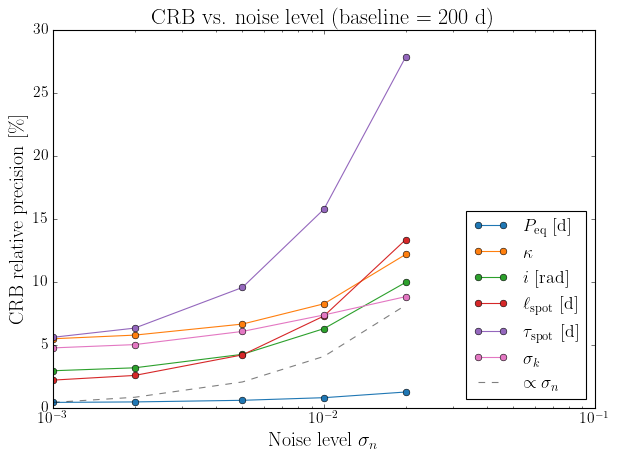

In [49]:
colors = plt.cm.tab10(np.linspace(0, 0.6, len(param_keys)))

fig, ax = plt.subplots(figsize=(8, 6))
for k, c in zip(param_keys, colors):
    idx = param_keys.index(k)
    rel = [s / abs(true_vals[idx]) * 100 for s in crb_vs_noise[k]]
    ax.semilogx(sigma_n_vals, rel, "o-", color=c, label=param_labels.get(k, k))

sn_ref = np.array(sigma_n_vals)
ref0   = crb_vs_noise["peq"][0] / true_params["peq"] * 100
ax.semilogx(sn_ref, ref0 * sn_ref / sn_ref[0], "k--", lw=1, alpha=0.5, label=r"$\propto\sigma_n$")

ax.set_xlabel(r"Noise level $\sigma_n$")
ax.set_ylabel(r"CRB relative precision [\%]")
ax.set_title(f"CRB vs. noise level (baseline = {tsim} d)")
ax.legend(fontsize=16, loc="lower right")
plt.tight_layout()
plt.show()

### Effect of observation baseline

A longer baseline samples more spot lifetimes and more rotation cycles, improving constraints on all parameters. Period precision in particular scales as $\sigma_P \propto 1/\sqrt{T}$.

In [50]:
baselines = [50, 100, 200, 400]
crb_vs_T  = {k: [] for k in param_keys}

for T in baselines:
    lc_T  = LightcurveModel.from_spot_model(model, nspot_rate=0.25, tsim=T, tsamp=tsamp)
    y_T   = lc_T.flux + np.random.normal(0, sigma_n, len(lc_T.t))
    ye_T  = np.full(len(lc_T.t), sigma_n)
    gp_T  = GPSolver(lc_T.t, y_T, ye_T, model, matrix_solver="cholesky_full").build_jax()
    cov_T = np.array(gp_T.mass_matrix_fisher(gp_T.theta0))
    for k, s in zip(param_keys, np.sqrt(np.diag(cov_T))):
        crb_vs_T[k].append(s)

JAX GP solver compiled in 2.84s
JAX GP solver recompute in 0.03s
JAX GP solver compiled in 2.92s
JAX GP solver recompute in 0.14s
JAX GP solver compiled in 3.02s
JAX GP solver recompute in 0.43s
JAX GP solver compiled in 3.77s
JAX GP solver recompute in 1.41s


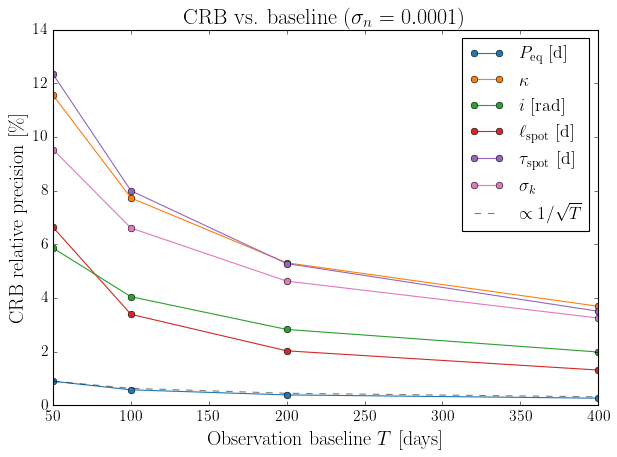

In [55]:
fig, ax = plt.subplots(figsize=(8, 6))
T_arr = np.array(baselines)
for k, c in zip(param_keys, colors):
    idx = param_keys.index(k)
    rel = [s / abs(true_vals[idx]) * 100 for s in crb_vs_T[k]]
    ax.plot(T_arr, rel, "o-", color=c, label=param_labels.get(k, k))

ref0 = crb_vs_T["peq"][0] / true_params["peq"] * 100
ax.plot(T_arr, ref0 * np.sqrt(T_arr[0] / T_arr), "k--", lw=1, alpha=0.5,
          label=r"$\propto 1/\sqrt{T}$")

ax.set_xlabel(r"Observation baseline $T$ [days]")
ax.set_ylabel(r"CRB relative precision [\%]")
ax.set_title(fr"CRB vs. baseline ($\sigma_n={sigma_n}$)")
ax.legend(fontsize=16, loc="upper right")
plt.tight_layout()
plt.show()

## Summary

The Cramér-Rao bound provides a rigorous, model-based floor on measurement uncertainty — independent of which fitting algorithm is used. Key takeaways:

| Observation | Physical reason |
|---|---|
| $P_{\rm eq}$ and $\sigma_k$ are typically best-constrained | They set the dominant period and amplitude of the GP covariance |
| $\kappa$ and $i$ are harder to constrain | They enter the kernel weakly and can be partially degenerate with each other |
| $\sigma_{\rm CRB} \propto \sigma_n$ | Precision scales directly with noise |
| $\sigma_{\rm CRB} \propto 1/\sqrt{T}$ | Longer baselines sample more independent data |
| Off-diagonal elements reveal degeneracies | e.g. $(\kappa, i)$ are often correlated because both affect the harmonic amplitudes |

In practice, the CRB is useful for **survey design** (how long do we need to observe?), **comparing datasets** (which target is most informative?), and **diagnosing degeneracies** before running expensive MCMC.